<a href="https://colab.research.google.com/github/srcorreia3001/srcorreia3001.github.io/blob/main/Projeto_de_ci%C3%AAncia_de_dados_evas%C3%A3o_escolar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

#URL do dataset oficial da UCI
URL = "https://archive.ics.uci.edu/static/public/697/predict+students+dropout+and+academic+success.zip"

#O pandas consegue ler direto o arquivo zip se especificamos o comportamento
DF = pd.read_csv(URL, sep=';')

#Visualizando as primeiras linhas e a estrutura
print(f"Formato do dataset: {DF.shape}")
print(DF['Target'].value_counts())

Formato do dataset: (4424, 37)
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


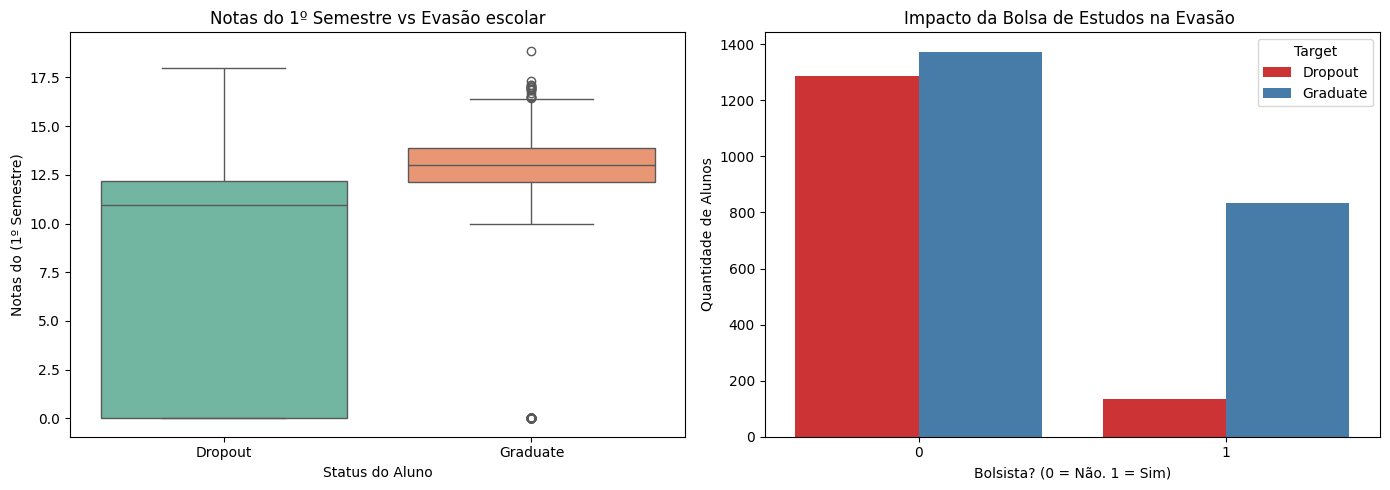

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Garantindo que os dados estejam carregados
URL = "https://archive.ics.uci.edu/static/public/697/predict+students+dropout+and+academic+success.zip"
DF = pd.read_csv(URL, sep=';')

# Filtrar o dataset para focar apenas em quem evadiu ou se formou
df_analise = DF[DF['Target'].isin(['Dropout','Graduate'])].copy()

# Configurando a figura do grafico
plt.figure(figsize=(14,5))

# Grafico 1: Notas do 1º Semestre vs Evasão
plt.subplot(1,2,1)
# Ajustado: adicionado hue='Target' e legend=False para evitar o FutureWarning
sns.boxplot(data=df_analise, x='Target', y='Curricular units 1st sem (grade)', hue='Target', palette='Set2', legend=False)
plt.title('Notas do 1º Semestre vs Evasão escolar')
plt.xlabel('Status do Aluno')
plt.ylabel('Notas do (1º Semestre)')

# Grafico 2: Impacto de ser Bolsista (Scholarship holder:1= Sim, 0= Não)
plt.subplot(1,2,2)
sns.countplot(data=df_analise, x='Scholarship holder', hue='Target', palette='Set1')
plt.title('Impacto da Bolsa de Estudos na Evasão ')
plt.xlabel('Bolsista? (0 = Não. 1 = Sim)')
plt.ylabel('Quantidade de Alunos')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

#1. Preparando os dados Filtrando e mapeando o Target para numérico
df_ml = DF[DF['Target'].isin(['Dropout', 'Graduate'])].copy()
df_ml['Target'] = df_ml['Target'].map({'Dropout':0, 'Graduate': 1})

#2. Separando as variáveis preditoras (X) e o alvo (Y)
x = df_ml.drop(columns=['Target'])
y = df_ml['Target']

#3. dividindo em treino (80%) e teste (20%)
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

#4. Treinando os modelos Random Forest
modelo = RandomForestClassifier(random_state=42, n_estimators=100)
modelo.fit(x_train, y_train)

#5. Fazendo previsões e avaliando
y_pred = modelo.predict(x_test)

print("----MÉTRICAS DO MODELO---")
print(f"Acurácia Geral: {accuracy_score(y_test, y_pred):.2%}\n")
print("Relatório de classificação:")
print(classification_report(y_test, y_pred, target_names=['Dropout','Graduate']))

----MÉTRICAS DO MODELO---
Acurácia Geral: 90.22%

Relatório de classificação:
              precision    recall  f1-score   support

     Dropout       0.91      0.83      0.87       277
    Graduate       0.90      0.95      0.92       449

    accuracy                           0.90       726
   macro avg       0.90      0.89      0.89       726
weighted avg       0.90      0.90      0.90       726

